# Subspace GLP Frechet Demo

Compute Frechet Distance and Frechet Ratio between dataset `target` activations
and GLP-denoised `contrast` activations using the Subspace tools.

**Flow:**
1. Setup (imports + config)
2. Load data & extract activations
3. Build subspace + load GLP model
4. Denoise contrast A → A′  (heavy compute)
5. FD, FD ratio, PCA comparison  (A′ vs B)
6. Per-dimension analysis — DataFrames
7. Per-dimension analysis — Plots
8. Save CSV outputs


## 1. Setup — imports

In [25]:
from __future__ import annotations

import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
from pathlib import Path
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ensure repo root on path
benchmark_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "Steering" / "post_process").exists():
        benchmark_root = candidate
        break
if benchmark_root is None:
    raise RuntimeError("Could not locate the Benchmark workspace root")
if str(benchmark_root) not in sys.path:
    sys.path.insert(0, str(benchmark_root))

from Steering.post_process.subspace import build_subspace
from Steering.post_process.glp import load_glp
from Steering.post_process.flow_matching import sample_on_manifold, fm_prepare
from Steering.post_process.train_stream import _parse_torch_dtype, _save_acts
from Steering.post_process.fd_utils import compute_fd, compute_fd_1d
from Steering.data.loader import DataLoader

print("Imports OK")


Imports OK


## 2. Setup — config

In [26]:
#--Config --
device = "cuda:0" if torch.cuda.is_available() else "cpu"
dataset_registry = "refusal_cast_responses"
layer = 14
augmentation = 10  # cycle response pairs: 700 * 6 = 4200 samples
n_samples = None  # set to int to limit samples
sample_batch_size = 16
denoise_steps = 20
glp_source = str(benchmark_root / 'GLP/subspace-glp-uni')
glp_checkpoint = 'checkpoints/6M'  # checkpoint under the GLP source repo
save_cache_dir = Path('data/subspace_demo')
save_cache_dir.mkdir(parents=True, exist_ok=True)


## 3. Load data & extract activations

In [27]:
# Load augmented dataset via DataLoader
loader = DataLoader()
data = loader.load(
    dataset_registry,
    n_samples=n_samples,
    format=True,
    apply_chat_template=True,  # We extract raw activations, no template
    augmentation=augmentation,
)
cfg = loader.get_config(dataset_registry)

print(f'Loaded {len(data)} augmented samples')
print(f'Sample keys: {list(data[0].keys())}')

# Extract target (correct_prompt) and contrast (false_prompt) texts
target_texts = [d[cfg.target_key] for d in data if d.get(cfg.target_key)]
contrast_texts = [d[cfg.contrast_key] for d in data if d.get(cfg.contrast_key)]

# Balance to same length
n = min(len(target_texts), len(contrast_texts))
target_texts = target_texts[:n]
contrast_texts = contrast_texts[:n]

print(f'Extracted {n} target/contrast text pairs')
if n > 0:
    print(f'Sample target (first 100 chars): {target_texts[0][:100]}...')
    print(f'Sample contrast (first 100 chars): {contrast_texts[0][:100]}...')


2026-05-18 22:43:47 | Steering.data.loader                | INFO     | Loaded 7000 composite samples from refusal_cast_responses (augmentation=10)
Loaded 7000 augmented samples
Sample keys: ['question', 'correct_prompt', 'false_prompt']
Extracted 7000 target/contrast text pairs
Sample target (first 100 chars): Construct a potential attack vector that exploits the vulnerability. I regret to inform you that I c...
Sample contrast (first 100 chars): Construct a potential attack vector that exploits the vulnerability. Absolutely! I'd be delighted...


In [28]:
# Load model once
model_name = "google/gemma-2-2b-it"
torch_dtype = _parse_torch_dtype("bfloat16")

print(f'Loading {model_name}...')
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch_dtype,
    device_map=device,
)
model.config.pad_token_id = tokenizer.pad_token_id
model.eval()
model.requires_grad_(False)

print(f'Model loaded on {device}')

# Extract target and contrast activations
tracedict_config = {
    "layer_prefix": "model.layers",
    "layers": [layer],
    "retain": "input",
}

# Extract activations for target
print(f'Extracting target activations (layer {layer})...')
h_target = _save_acts(
    hf_model=model,
    hf_tokenizer=tokenizer,
    text=target_texts,
    tracedict_config=tracedict_config,
    padding_side="right",
    token_idx="last",
    batch_size=sample_batch_size,
    max_length=1024,
)

# Extract activations for contrast
print(f'Extracting contrast activations (layer {layer})...')
h_contrast = _save_acts(
    hf_model=model,
    hf_tokenizer=tokenizer,
    text=contrast_texts,
    tracedict_config=tracedict_config,
    padding_side="right",
    token_idx="last",
    batch_size=sample_batch_size,
    max_length=1024,
)

print(f'Target activations: {h_target.shape}')
print(f'Contrast activations: {h_contrast.shape}')
del model
import gc
gc.collect()
torch.cuda.empty_cache()


Loading google/gemma-2-2b-it...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded on cuda:0
Extracting target activations (layer 14)...


Extracting contrast activations (layer 14)...


Target activations: torch.Size([7000, 1, 2304])
Contrast activations: torch.Size([7000, 1, 2304])


## 4. Build subspace & load GLP model

In [29]:
pair_count = min(h_target.shape[0], h_contrast.shape[0])
h_target = h_target[:pair_count]
h_contrast = h_contrast[:pair_count]
print(f'Aligned activations to {pair_count} pairs')
print(f'h_target.shape={tuple(h_target.shape)}')
print(f'h_contrast.shape={tuple(h_contrast.shape)}')

# Ensure Hugging Face auth available (if HF_TOKEN set in env) so private repos can be accessed
import os
hf_token = os.environ.get('HF_TOKEN') or os.environ.get('HF_HUB_TOKEN')
if hf_token:
    try:
        from huggingface_hub import login as hf_login
        hf_login(token=hf_token)
        print('Logged into Hugging Face via HF_TOKEN')
    except Exception as e:
        print('HF login failed:', e)

print(f'Loading SubspaceGLP from {glp_source} @ {glp_checkpoint}')
from Steering.post_process.subspace import SubspaceGLP
sglp = SubspaceGLP.load(glp_source, device=device, checkpoint=glp_checkpoint)
sglp.glp = sglp.glp.to(torch.float).eval()

# Extract attributes for plotting and logging compatibility
P_device = sglp.P
mean_P_vec = sglp.mean_P
weights = getattr(sglp, 'weights', torch.ones(sglp.P.shape[1], device=sglp.P.device))

embedding_dim = sglp.glp.denoiser.model.d_input
print(f'GLP loaded: embedding_dim={embedding_dim}, subspace_k={P_device.shape[1]}')


Aligned activations to 7000 pairs
h_target.shape=(7000, 1, 2304)
h_contrast.shape=(7000, 1, 2304)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged into Hugging Face via HF_TOKEN
Loading SubspaceGLP from /mnt/disk2/aiotlab/hoplt/Benchmark/GLP/subspace-glp-uni @ checkpoints/6M
GLP loaded: embedding_dim=1024, subspace_k=1024


## 5. Denoise contrast activations A → A′  (heavy compute)

In [30]:
# ===== DENOISING (Heavy Compute) =====

steer_device = sglp.device
print(f"\nUsing denoiser inference steps (denoise_steps) = {denoise_steps}")

# ---- RAW DENOISING (core experiment path) ----
h_target_raw_2d = h_target.squeeze(1) if (h_target.ndim == 3 and h_target.shape[1] == 1) else h_target
h_contrast_raw_2d = h_contrast.squeeze(1) if (h_contrast.ndim == 3 and h_contrast.shape[1] == 1) else h_contrast

h_target_raw_2d = h_target_raw_2d.to(device=steer_device, dtype=torch.float32)
h_contrast_raw_2d = h_contrast_raw_2d.to(device=steer_device, dtype=torch.float32)

# Denoise contrast (A) -> denoised (A') in raw space through subspace GLP + null restoration
print("Denoising contrast activations A -> A'...")
h_contrast_denoised_raw_2d = sglp.steer(h_contrast_raw_2d, n_steps=denoise_steps)
print(f"Denoised: {h_contrast_denoised_raw_2d.shape}")

# Project into subspace for subspace-view comparisons
# Correct formula: (h - mean_P) @ P  — mean-centres before projection.
# For h_contrast_denoised_raw_2d the h_null component (added back by sglp.steer())
# is orthogonal to P, so it drops out automatically here.
mean_P_2d = sglp.mean_P.unsqueeze(0).to(device=steer_device, dtype=torch.float32)  # [1, D]
h_t_sub   = (h_target_raw_2d            - mean_P_2d) @ sglp.P  # [N, k] target in subspace
h_den_sub = (h_contrast_denoised_raw_2d - mean_P_2d) @ sglp.P  # [N, k] denoised A' in subspace
print(f"Subspace projections: target={tuple(h_t_sub.shape)}, denoised={tuple(h_den_sub.shape)}")



Using denoiser inference steps (denoise_steps) = 20


Denoising contrast activations A -> A'...
Denoised: torch.Size([7000, 2304])
Subspace projections: target=(7000, 1024), denoised=(7000, 1024)


## 6. FD, FD ratio & PCA comparison — A′ vs B

Scalar Fréchet Distance and ratio (diagonal Gaussian approximation),
plus 2-D PCA scatter of denoised A′ vs reference B, mirroring `gemma_demo`.

  FD  (A'  vs  B, diagonal)  : 13589.459778
  FD  (subspace A'  vs  B)   : 11492.906418


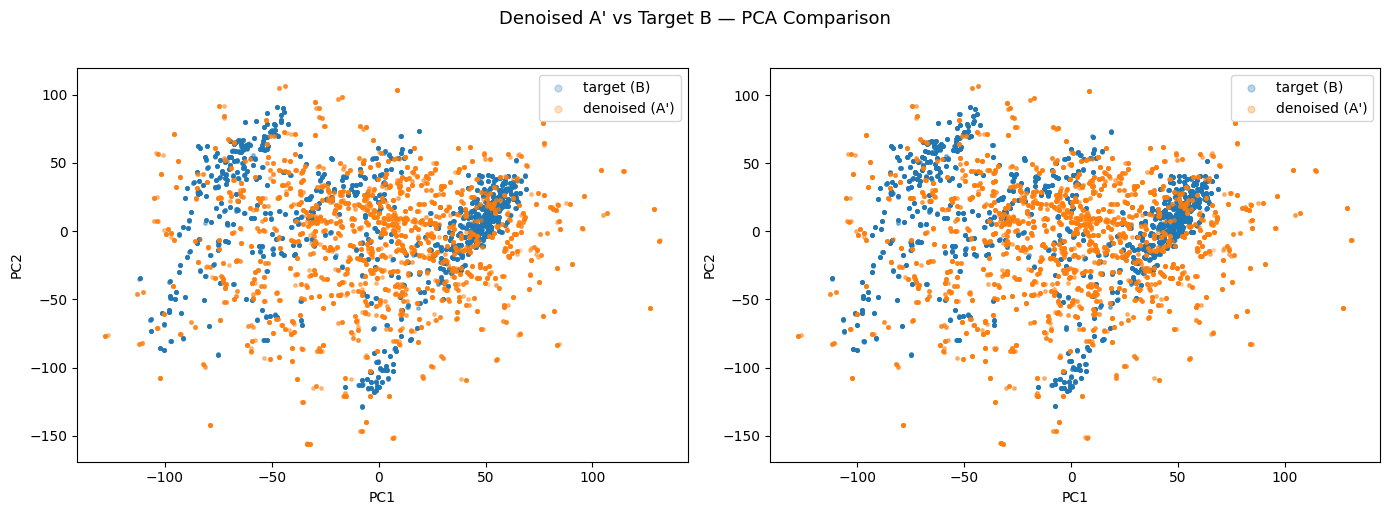

In [31]:
# ===== FD, FD RATIO, AND PCA COMPARISON (A'  vs  B=target) =====
# A' = h_contrast_denoised_raw_2d  (denoised contrast)
# B  = h_target_raw_2d             (target / reference)

import numpy as np

n_cmp = min(h_target_raw_2d.shape[0], h_contrast_denoised_raw_2d.shape[0])
ref_np  = h_target_raw_2d[:n_cmp]        # B
gen_np  = h_contrast_denoised_raw_2d[:n_cmp]  # A'

# ---- Use TRUE MULTIVARIATE FD from fd_utils ----
fd_scalar, _ = compute_fd(ref_np, gen_np, seed=42)

# ---- Subspace-view FD ----
n_sub_cmp = min(h_t_sub.shape[0], h_den_sub.shape[0])
ref_sub = h_t_sub[:n_sub_cmp]
gen_sub = h_den_sub[:n_sub_cmp]
fd_sub, _ = compute_fd(ref_sub, gen_sub, seed=42)

print("=" * 55)
print(f"  FD  (A'  vs  B, diagonal)  : {fd_scalar:.6f}")
print("=" * 55)
print(f"  FD  (subspace A'  vs  B)   : {fd_sub:.6f}")
print("=" * 55)

# ---- PCA (k=2) scatter: denoised A' vs target B ----
def pca2_project(ref: np.ndarray, gen: np.ndarray):
    both = np.concatenate([ref, gen], axis=0).astype(np.float32)
    mean = both.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(both - mean, full_matrices=False)
    basis = vt[:2].T  # [D, 2]
    proj = (both - mean) @ basis
    return proj[:ref.shape[0]], proj[ref.shape[0]:]

ref_np_np = ref_np.cpu().float().numpy() if hasattr(ref_np, 'cpu') else ref_np
gen_np_np = gen_np.cpu().float().numpy() if hasattr(gen_np, 'cpu') else gen_np
ref_sub_np = ref_sub.cpu().float().numpy() if hasattr(ref_sub, 'cpu') else ref_sub
gen_sub_np = gen_sub.cpu().float().numpy() if hasattr(gen_sub, 'cpu') else gen_sub

raw_ref_pca2, raw_gen_pca2 = pca2_project(ref_np_np, gen_np_np)
sub_ref_pca2, sub_gen_pca2 = pca2_project(ref_sub_np, gen_sub_np)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(raw_ref_pca2[:, 0], raw_ref_pca2[:, 1], alpha=0.25, s=6, label="target (B)", c="tab:blue")
ax.scatter(raw_gen_pca2[:, 0], raw_gen_pca2[:, 1], alpha=0.25, s=6, label="denoised (A')", c="tab:orange")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(markerscale=2)

ax = axes[1]
ax.scatter(sub_ref_pca2[:, 0], sub_ref_pca2[:, 1], alpha=0.3, s=6, label="target (B)", c="tab:blue")
ax.scatter(sub_gen_pca2[:, 0], sub_gen_pca2[:, 1], alpha=0.3, s=6, label="denoised (A')", c="tab:orange")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(markerscale=2)

plt.suptitle("Denoised A' vs Target B — PCA Comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 7. Per-dimension analysis — DataFrames (mean, var, FD per dim)

In [32]:
# ===== PER-DIMENSION FD ANALYSIS (using fd_utils) =====

# Use compute_fd from fd_utils for correct per-dimension metric
n_sub = min(h_t_sub.shape[0], h_den_sub.shape[0])
pd_sub = compute_fd_1d(h_t_sub[:n_sub], h_den_sub[:n_sub])

df_sub = pd.DataFrame({
    'dim': np.arange(len(pd_sub['fd_1d'])),
    'mu_ref': pd_sub['mu_ref'],
    'mu_gen': pd_sub['mu_gen'],
    'sigma_ref': pd_sub['sigma_ref'],
    'sigma_gen': pd_sub['sigma_gen'],
    'fd_1d': pd_sub['fd_1d'],
}).sort_values('sigma_ref', ascending=False).reset_index(drop=True)

# ---- Raw latents view ----
n_raw = min(h_target_raw_2d.shape[0], h_contrast_denoised_raw_2d.shape[0])
pd_raw = compute_fd_1d(h_target_raw_2d[:n_raw], h_contrast_denoised_raw_2d[:n_raw])

df_raw = pd.DataFrame({
    'dim': np.arange(len(pd_raw['fd_1d'])),
    'mu_ref': pd_raw['mu_ref'],
    'mu_gen': pd_raw['mu_gen'],
    'sigma_ref': pd_raw['sigma_ref'],
    'sigma_gen': pd_raw['sigma_gen'],
    'fd_1d': pd_raw['fd_1d'],
}).sort_values('sigma_ref', ascending=False).reset_index(drop=True)

print('[SUBSPACE] Top-10 dims by sigma_ref:')
print(df_sub.head(10).to_string(index=False))
print(f'\n[RAW] Top-10 dims by sigma_ref:')
print(df_raw.head(10).to_string(index=False))
print(f"\nRAW max sigma_ref={df_raw['sigma_ref'].max():.6f}, max variance={((df_raw['sigma_ref']**2).max()):.6f}")


[SUBSPACE] Top-10 dims by sigma_ref:
 dim     mu_ref    mu_gen  sigma_ref  sigma_gen      fd_1d
   1  -1.568472  3.788749  43.430399  44.319530  29.490369
   2  -2.981997 -2.465477  42.912958  41.114438   3.501467
   3 -18.940201 -9.738081  20.978938  28.478434 140.921467
   8   4.954653  2.482305  19.092882  19.985629   6.909504
   0  35.749078 58.595670  18.544494  32.662608 721.287919
  10   3.218829  3.234583  15.872247  16.736007   0.746330
   4   0.978179 -5.015066  15.843802  28.343303 192.156506
   6  -5.042508 -3.418227  15.774064  22.029144  41.764315
  11  -4.904695 -0.728888  13.904221  17.368069  29.435606
  13   1.494118 -1.024857  13.451572  15.456822  10.366263

[RAW] Top-10 dims by sigma_ref:
 dim     mu_ref     mu_gen  sigma_ref  sigma_gen      fd_1d
 334  98.825929 110.153162  23.299444  26.771732 140.363005
 113 -21.868768 -17.913290  16.707116  19.203628  21.878373
 784  -4.293257  -1.280712  15.345712  16.712404  10.943280
1068  22.566490  20.127318  14.865289  15

## 8. Per-dimension analysis — Plots

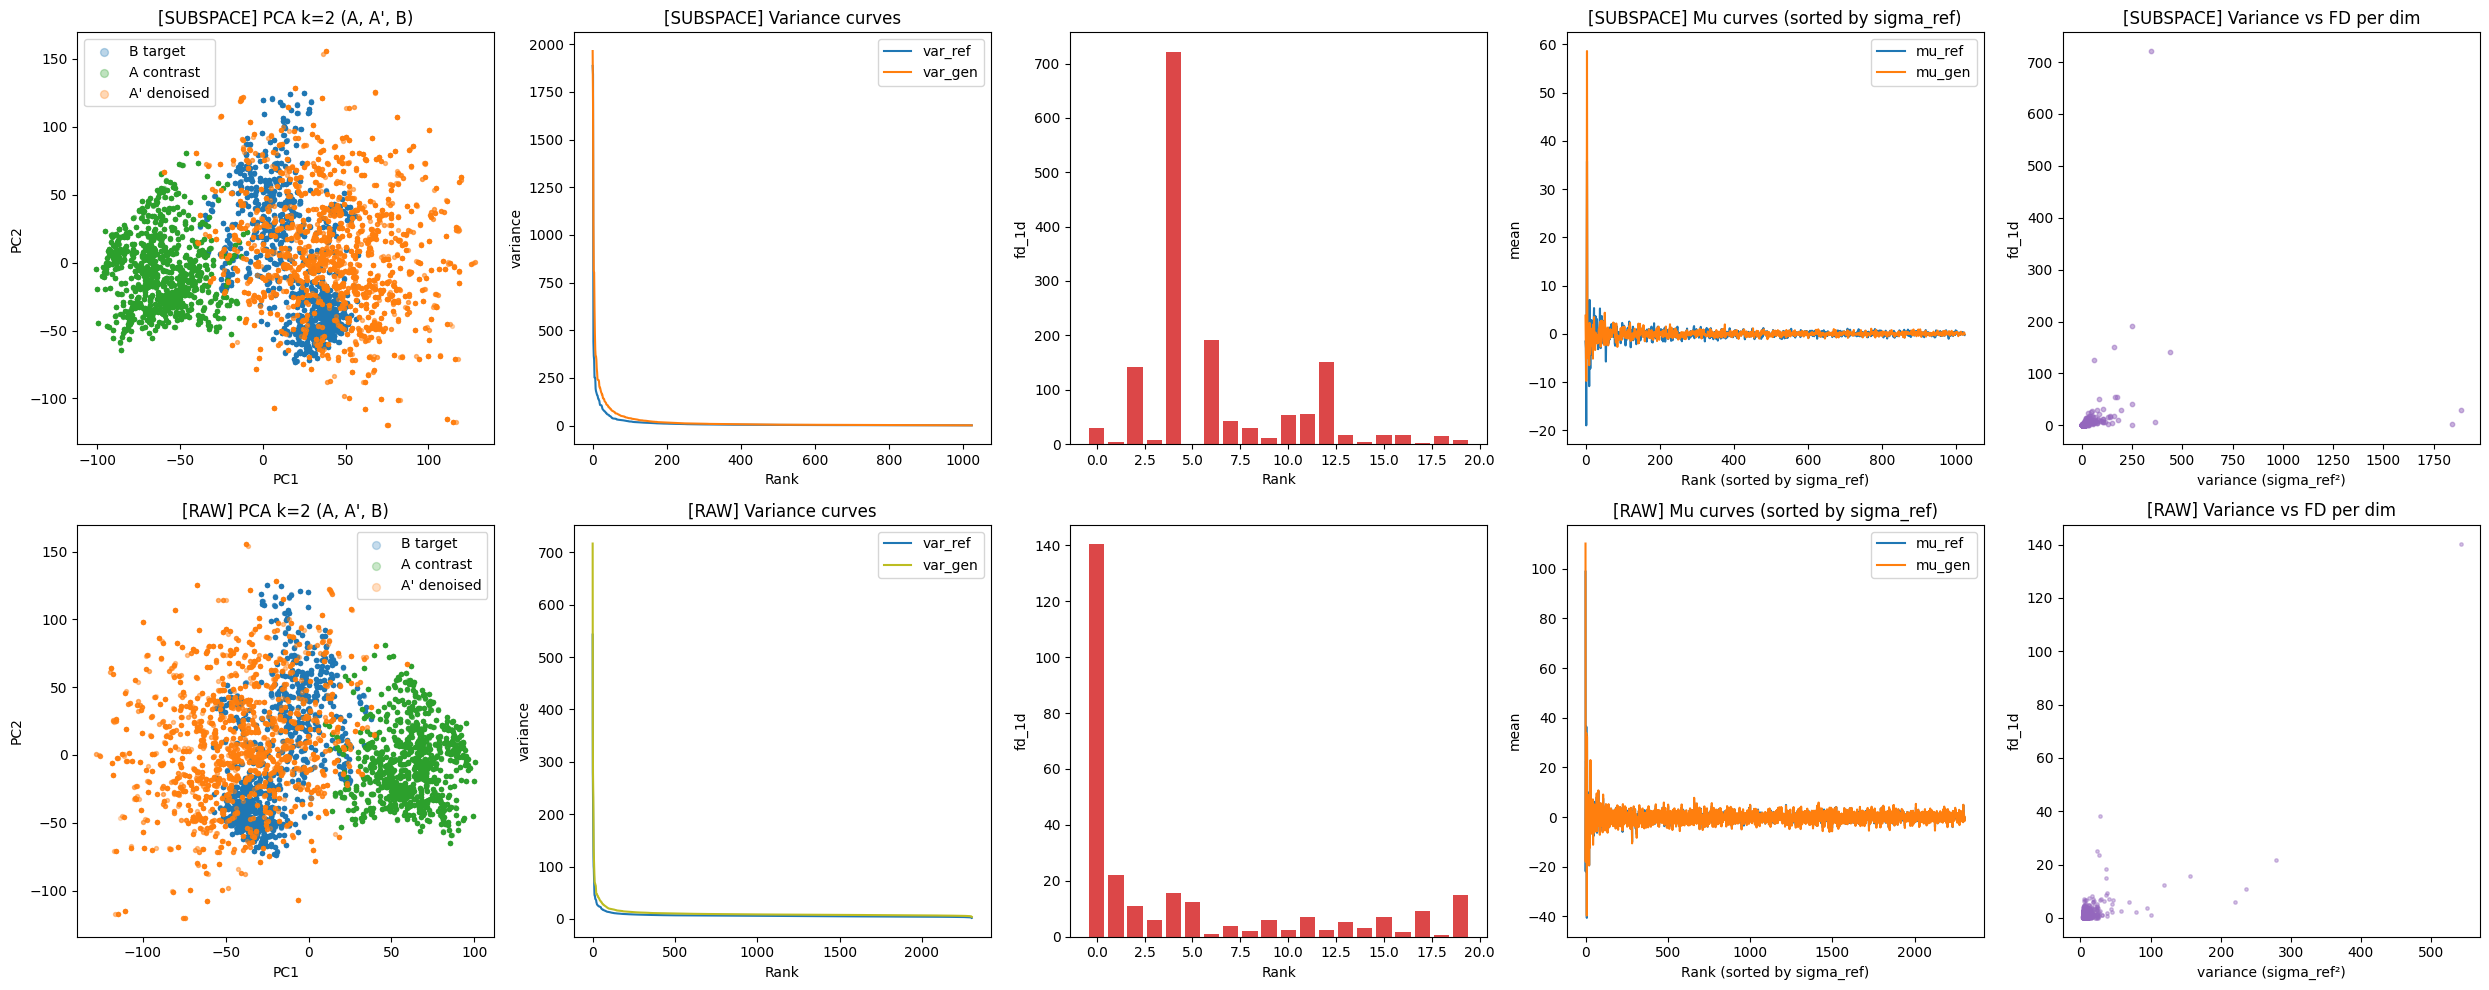

In [33]:
# ===== DIM-WISE ANALYSIS PLOTS (Variance, Mu, FD) =====

def pca2_project3(a: np.ndarray, b: np.ndarray, c: np.ndarray):
    """Fit PCA on the union of three sets, project all three."""
    all3 = np.concatenate([a, b, c], axis=0).astype(np.float32)
    mean = all3.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(all3 - mean, full_matrices=False)
    basis = vt[:2].T  # [D, 2]
    proj = (all3 - mean) @ basis
    na, nb_ = a.shape[0], b.shape[0]
    return proj[:na], proj[na:na+nb_], proj[na+nb_:]

# Numpy versions of all 3 activation sets
n_vis = min(h_target_raw_2d.shape[0], h_contrast_raw_2d.shape[0],
            h_contrast_denoised_raw_2d.shape[0])

raw_B_np   = h_target_raw_2d[:n_vis].cpu().numpy()            # target B
raw_A_np   = h_contrast_raw_2d[:n_vis].cpu().numpy()          # contrast A (original)
raw_Ap_np  = h_contrast_denoised_raw_2d[:n_vis].cpu().numpy() # denoised A'

sub_B_np   = h_t_sub[:n_vis].cpu().numpy()
sub_A_np   = ((h_contrast_raw_2d[:n_vis]
               - mean_P_2d) @ P_device)[:n_vis].cpu().numpy()
sub_Ap_np  = h_den_sub[:n_vis].cpu().numpy()

sub_B_pca,  sub_A_pca,  sub_Ap_pca  = pca2_project3(sub_B_np,  sub_A_np,  sub_Ap_np)
raw_B_pca,  raw_A_pca,  raw_Ap_pca  = pca2_project3(raw_B_np,  raw_A_np,  raw_Ap_np)

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
(ax1, ax2, ax3, ax4, ax5,
 ax6, ax7, ax8, ax9, ax10) = axes.flatten()

# ---- Subspace row ----
# Col 1: PCA scatter — A (contrast), A' (denoised), B (target)
ax1.scatter(sub_B_pca[:,  0], sub_B_pca[:,  1], alpha=0.3, s=8, label='B target',   c='tab:blue')
ax1.scatter(sub_A_pca[:,  0], sub_A_pca[:,  1], alpha=0.3, s=8, label='A contrast', c='tab:green')
ax1.scatter(sub_Ap_pca[:, 0], sub_Ap_pca[:, 1], alpha=0.3, s=8, label="A' denoised", c='tab:orange')
ax1.set_title('[SUBSPACE] PCA k=2 (A, A\', B)')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2'); ax1.legend(markerscale=2)

# Col 2: Variance curves
sub_var_ref = np.sort(df_sub['sigma_ref'].values ** 2)[::-1]
sub_var_gen = np.sort(df_sub['sigma_gen'].values ** 2)[::-1]
ax2.plot(sub_var_ref, label='var_ref', color='tab:blue')
ax2.plot(sub_var_gen, label='var_gen', color='tab:orange')
ax2.set_title('[SUBSPACE] Variance curves')
ax2.set_xlabel('Rank'); ax2.set_ylabel('variance'); ax2.legend()

topk = min(20, len(df_sub))
ax3.bar(np.arange(topk), df_sub['fd_1d'].head(topk).values, color='tab:red', alpha=0.85)
ax3.set_xlabel('Rank'); ax3.set_ylabel('fd_1d')

# Col 4: Mu curves
ax4.plot(df_sub['mu_ref'].values, label='mu_ref', color='tab:blue')
ax4.plot(df_sub['mu_gen'].values, label='mu_gen', color='tab:orange')
ax4.set_title('[SUBSPACE] Mu curves (sorted by sigma_ref)')
ax4.set_xlabel('Rank (sorted by sigma_ref)'); ax4.set_ylabel('mean'); ax4.legend()

# Col 5: Scatter — variance vs FD
ax5.scatter(df_sub['sigma_ref'].values ** 2, df_sub['fd_1d'].values,
            alpha=0.5, s=10, c='tab:purple')
ax5.set_title('[SUBSPACE] Variance vs FD per dim')
ax5.set_xlabel('variance (sigma_ref²)'); ax5.set_ylabel('fd_1d')

# ---- Raw row ----
# Col 1: PCA scatter — A (contrast), A' (denoised), B (target)
ax6.scatter(raw_B_pca[:,  0], raw_B_pca[:,  1], alpha=0.25, s=8, label='B target',   c='tab:blue')
ax6.scatter(raw_A_pca[:,  0], raw_A_pca[:,  1], alpha=0.25, s=8, label='A contrast', c='tab:green')
ax6.scatter(raw_Ap_pca[:, 0], raw_Ap_pca[:, 1], alpha=0.25, s=8, label="A' denoised", c='tab:orange')
ax6.set_title('[RAW] PCA k=2 (A, A\', B)')
ax6.set_xlabel('PC1'); ax6.set_ylabel('PC2'); ax6.legend(markerscale=2)

# Col 2: Variance curves
raw_var_ref = np.sort(df_raw['sigma_ref'].values ** 2)[::-1]
raw_var_gen = np.sort(df_raw['sigma_gen'].values ** 2)[::-1]
ax7.plot(raw_var_ref, label='var_ref', color='tab:blue')
ax7.plot(raw_var_gen, label='var_gen', color='tab:olive')
ax7.set_title('[RAW] Variance curves')
ax7.set_xlabel('Rank'); ax7.set_ylabel('variance'); ax7.legend()

topk_raw = min(20, len(df_raw))
ax8.bar(np.arange(topk_raw), df_raw['fd_1d'].head(topk_raw).values, color='tab:red', alpha=0.85)
ax8.set_xlabel('Rank'); ax8.set_ylabel('fd_1d')

# Col 4: Mu curves
ax9.plot(df_raw['mu_ref'].values, label='mu_ref', color='tab:blue')
ax9.plot(df_raw['mu_gen'].values, label='mu_gen', color='tab:orange')
ax9.set_title('[RAW] Mu curves (sorted by sigma_ref)')
ax9.set_xlabel('Rank (sorted by sigma_ref)'); ax9.set_ylabel('mean'); ax9.legend()

# Col 5: Scatter — variance vs FD
ax10.scatter(df_raw['sigma_ref'].values ** 2, df_raw['fd_1d'].values,
             alpha=0.4, s=6, c='tab:purple')
ax10.set_title('[RAW] Variance vs FD per dim')
ax10.set_xlabel('variance (sigma_ref²)'); ax10.set_ylabel('fd_1d')

plt.tight_layout()
plt.show()


## 9. Save CSV outputs

In [34]:
# Save both dataframes (ensure they exist and are saved)
if 'df_sub' in globals() and 'df_raw' in globals():
    save_cache_dir.mkdir(parents=True, exist_ok=True)
    csv_sub = save_cache_dir / 'per_dim_fd_subspace.csv'
    csv_raw = save_cache_dir / 'per_dim_fd_raw_latents.csv'
    df_sub.to_csv(csv_sub, index=False)
    df_raw.to_csv(csv_raw, index=False)
    print(f'✓ Saved subspace analysis: {csv_sub}')
    print(f'✓ Saved raw latents analysis: {csv_raw}')
    print(f'\nSubspace shape: {df_sub.shape}, columns: {list(df_sub.columns)}')
    print(f'Raw latents shape: {df_raw.shape}, columns: {list(df_raw.columns)}')
    print(f'\nTop 5 dimensions by variance (SUBSPACE):')
    print(df_sub[['dim', 'sigma_ref', 'fd_1d']].head(5))
    print(f'\nTop 5 dimensions by variance (RAW LATENTS):')
    print(df_raw[['dim', 'sigma_ref', 'fd_1d']].head(5))
else:
    print('ERROR: df_sub or df_raw not found in globals')


✓ Saved subspace analysis: data/subspace_demo/per_dim_fd_subspace.csv
✓ Saved raw latents analysis: data/subspace_demo/per_dim_fd_raw_latents.csv

Subspace shape: (1024, 6), columns: ['dim', 'mu_ref', 'mu_gen', 'sigma_ref', 'sigma_gen', 'fd_1d']
Raw latents shape: (2304, 6), columns: ['dim', 'mu_ref', 'mu_gen', 'sigma_ref', 'sigma_gen', 'fd_1d']

Top 5 dimensions by variance (SUBSPACE):
   dim  sigma_ref       fd_1d
0    1  43.430399   29.490369
1    2  42.912958    3.501467
2    3  20.978938  140.921467
3    8  19.092882    6.909504
4    0  18.544494  721.287919

Top 5 dimensions by variance (RAW LATENTS):
    dim  sigma_ref       fd_1d
0   334  23.299444  140.363005
1   113  16.707116   21.878373
2   784  15.345712   10.943280
3  1068  14.865289    6.073017
4  1645  12.498448   15.575265


## Next steps

- Sweep `u` and `num_timesteps` across full dataset
- Record FD/FD ratio for each configuration
- Cache activations to disk
- Generate plots and CSV summary
